In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import random

In [2]:
import shutil
from pathlib import Path
import pandas as pd

# ===============================
# CONFIG
# ===============================
IMG_PREFIX = "mz_binary_"
IMG_EXT = ".png"

# Dataset A
A_IMG_DIR = Path("../images/corrected")
A_CSV     = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected/training_index.csv")

# Dataset B
B_IMG_DIR = Path("../images/corrected_2")
B_CSV     = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_2/training_index.csv")

# Output (nuevo dataset)
OUT_IMG_DIR = Path("../dataset_combined/images")
OUT_CSV     = Path("../dataset_combined/training_index.csv")

OUT_IMG_DIR.mkdir(parents=True, exist_ok=True)

# ===============================
# LOAD CSVs (FIXED)
# ===============================
df_A = pd.read_csv(A_CSV, index_col=0)
df_B = pd.read_csv(B_CSV, index_col=0)

# Name the index properly
df_A.index.name = "run_id"
df_B.index.name = "run_id"

# ===============================
# SANITY CHECKS
# ===============================
assert "sigma" in df_A.columns, "Dataset A must have column 'sigma'"
assert "sigma_nominal" in df_B.columns, "Dataset B must have 'sigma_nominal'"

# ===============================
# COPY DATASET A
# ===============================
print("Copying dataset A images...")

for run_id in df_A.index:
    src = A_IMG_DIR / f"{IMG_PREFIX}{run_id}{IMG_EXT}"
    dst = OUT_IMG_DIR / f"{IMG_PREFIX}{run_id}{IMG_EXT}"

    if not src.exists():
        raise FileNotFoundError(src)

    shutil.copy2(src, dst)

print(f"  -> {len(df_A)} images copied")

# ===============================
# PREPARE DATASET B
# ===============================
print("Preparing dataset B...")

df_B = df_B.copy()

# Unify sigma definition
df_B["sigma"] = df_B["sigma_nominal"]

offset = int(df_A.index.max())

new_rows = []

for run_id, row in df_B.iterrows():
    new_id = int(run_id) + offset

    src = B_IMG_DIR / f"{IMG_PREFIX}{run_id}{IMG_EXT}"
    dst = OUT_IMG_DIR / f"{IMG_PREFIX}{new_id}{IMG_EXT}"

    if not src.exists():
        raise FileNotFoundError(src)

    shutil.copy2(src, dst)

    new_row = row.copy()
    new_row.name = new_id
    new_rows.append(new_row)

df_B_new = pd.DataFrame(new_rows)
df_B_new.index.name = "run_id"

print(f"  -> {len(df_B_new)} images copied and reindexed")

# ===============================
# MERGE CSVs
# ===============================
df_combined = pd.concat([df_A, df_B_new])
df_combined = df_combined.sort_index()

df_combined.to_csv(OUT_CSV)

print("\n✅ Combined dataset created successfully")
print(f"Images folder: {OUT_IMG_DIR}")
print(f"CSV file:      {OUT_CSV}")
print(f"Total samples: {len(df_combined)}")
print("Columns:", list(df_combined.columns))


Copying dataset A images...
  -> 506 images copied
Preparing dataset B...
  -> 591 images copied and reindexed

✅ Combined dataset created successfully
Images folder: ../dataset_combined/images
CSV file:      ../dataset_combined/training_index.csv
Total samples: 1097
Columns: ['sample_idx', 'realization', 'Dind', 'Ku1', 'Aex', 'alpha', 'Temp', 'sigma', 'mx3_path', 'out_dir', 'returncode', 'timestamp_start', 'timestamp_end', 'sigma_nominal', 'sigma_eff', 'clamp_fraction']


In [2]:
# -----------------------------
# 1) Config 
# -----------------------------
CSV_PATH = Path("../dataset_combined/training_index.csv")
IMG_DIR = Path("../dataset_combined/images")
#CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_2/training_index.csv")
#IMG_DIR = Path("../images/corrected_2")
IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma"

IMG_EXT = ".png"   # image extension
IMG_PREFIX = "mz_binary_"   # image name pattern: mz_binary_<idx>.png

BATCH_SIZE = 10
LR = 5e-5
EPOCHS = 100
VAL_RATIO = 0.15
RANDOM_SEED = 5    #42
MODEL_TYPE = "physics_normal"   # Options: "resnet", "physics", "normal", "physics_normal" 
TRAIN_SURROGATE = True   # whether to train surrogate model or load pre-trained weights
USE_AUGMENTATION = False   # True / False para la prueba

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

#-----------------------------------------------------------------

RUN_TAG = "FFT_corr"   # híbrido: física FFT + correlación
OUT_DIR = Path(f"./outputs/{RUN_TAG}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR  = OUT_DIR / "figures"
MET_DIR  = OUT_DIR / "metrics"

for d in [CKPT_DIR, FIG_DIR, MET_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
PINN_CKPT_PATH = CKPT_DIR / f"pinn_{RUN_TAG}.pt"
SURR_FFT_PATH  = CKPT_DIR / f"surrogate_fft_{RUN_TAG}.pt"
SURR_CORR_PATH = CKPT_DIR / f"surrogate_corr_{RUN_TAG}.pt"
SURR_PHI_PATH  = CKPT_DIR / f"surrogate_phi_{RUN_TAG}.pt"
SCALER_PATH    = CKPT_DIR / f"scalers_{RUN_TAG}.pkl"

LOSS_PLOT_PATH     = FIG_DIR / f"loss_curves_{RUN_TAG}.png"
HEATMAP_D_PATH     = FIG_DIR / f"heatmap_err_D_{RUN_TAG}.png"
HEATMAP_SIGMA_PATH = FIG_DIR / f"heatmap_err_sigma_{RUN_TAG}.png"

PRED_IMG_DIR = OUT_DIR / "pred_images"
PRED_IMG_DIR.mkdir(parents=True, exist_ok=True)


Device: cuda


In [3]:
def compute_corr_observables(img_batch, n_radial_bins=64):
    """
    Physics-informed REAL-SPACE observables based on spatial correlations C(r).

    Phi_corr =
    [
        C(1), C(2), ..., C(R),
        L_corr
    ]

    Sensitive mainly to disorder (sigma).
    """

    # ---------------------------------------------
    # 1) mz channel in [-1, 1]
    # ---------------------------------------------
    x = img_batch[:, 0, :, :]          # [B, H, W]
    x = 2.0 * x - 1.0

    B, H, W = x.shape
    eps = 1e-8

    # ---------------------------------------------
    # 2) Remove spatial mean (critical)
    # ---------------------------------------------
    x = x - x.mean(dim=(1, 2), keepdim=True)

    # ---------------------------------------------
    # 3) Autocorrelation via Wiener–Khinchin theorem
    # ---------------------------------------------
    Fx = torch.fft.fft2(x)
    P = Fx.real**2 + Fx.imag**2
    C = torch.fft.ifft2(P).real

    # Normalize so that C(0) = 1
    C0 = C[:, 0, 0].clamp_min(eps)
    C = C / C0[:, None, None]

    # ---------------------------------------------
    # 4) Radial distance grid (pixel units)
    # ---------------------------------------------
    yy = torch.fft.fftfreq(H, device=x.device) * H
    xx = torch.fft.fftfreq(W, device=x.device) * W
    Y, X = torch.meshgrid(yy, xx, indexing="ij")
    r = torch.sqrt(X**2 + Y**2)

    r_int = torch.round(r).long()
    max_r = min(n_radial_bins, r_int.max().item())

    # ---------------------------------------------
    # 5) Isotropic radial averaging → C(r)
    # ---------------------------------------------
    C_flat = C.reshape(B, -1)
    r_flat = r_int.reshape(-1)

    Cr = []
    for rr in range(1, max_r + 1):
        mask = (r_flat == rr).float()
        denom = mask.sum().clamp_min(1.0)
        Cr_r = (C_flat * mask).sum(dim=1) / denom
        Cr.append(Cr_r)

    Cr = torch.stack(Cr, dim=1)  # [B, R]

    # Pad to fixed length if needed
    if Cr.shape[1] < n_radial_bins:
        pad = torch.zeros(B, n_radial_bins - Cr.shape[1], device=x.device)
        Cr = torch.cat([Cr, pad], dim=1)

    # ---------------------------------------------
    # 6) Correlation length L_corr
    #    (first zero crossing)
    # ---------------------------------------------
    sign = torch.sign(Cr)
    zero_cross = (sign[:, :-1] * sign[:, 1:] < 0)

    L_corr = torch.where(
        zero_cross.any(dim=1),
        zero_cross.float().argmax(dim=1) + 1,
        torch.full((B,), float(n_radial_bins), device=x.device)
    )

    # ---------------------------------------------
    # 7) Final Phi_corr
    # ---------------------------------------------
    Phi_corr = torch.cat(
        [
            Cr,
            L_corr.unsqueeze(1)
        ],
        dim=1
    )

    return Phi_corr


def compute_fft_observables(img_batch, n_radial_bins=64):
    """
    Physics-informed FOURIER-SPACE observables based on isotropic power spectrum.

    Phi_fft =
    [
        S_norm(k_1)...S_norm(k_n),
        <k>, Var(k), Skew(k), Kurt(k),
        peak_ratio, high_k_energy
    ]

    Sensitive mainly to periodicity and DMI strength (D).
    """

    # ---------------------------------------------
    # 1) mz channel in [-1, 1]
    # ---------------------------------------------
    x = img_batch[:, 0, :, :]          # [B, H, W]
    x = 2.0 * x - 1.0

    B, H, W = x.shape
    eps = 1e-8

    # ---------------------------------------------
    # 2) Remove DC component
    # ---------------------------------------------
    x = x - x.mean(dim=(1, 2), keepdim=True)

    # ---------------------------------------------
    # 3) Fourier transform and power spectrum
    # ---------------------------------------------
    F = torch.fft.fft2(x)
    F = torch.fft.fftshift(F, dim=(1, 2))
    P = torch.log1p(torch.abs(F) ** 2)

    # ---------------------------------------------
    # 4) Radial wavevector grid (dimensionless)
    # ---------------------------------------------
    yy, xx = torch.meshgrid(
        torch.linspace(-1, 1, H, device=x.device),
        torch.linspace(-1, 1, W, device=x.device),
        indexing="ij"
    )
    k = torch.sqrt(xx**2 + yy**2)

    k_flat = k.reshape(-1)
    P_flat = P.reshape(B, -1)

    k_max = k_flat.max()
    bin_edges = torch.linspace(0.0, k_max, n_radial_bins + 1, device=x.device)
    k_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # ---------------------------------------------
    # 5) Isotropic radial averaging → S(k)
    # ---------------------------------------------
    S_bins = []
    for i in range(n_radial_bins):
        mask = (k_flat >= bin_edges[i]) & (k_flat < bin_edges[i + 1])
        mask = mask.unsqueeze(0)

        denom = mask.sum(dim=1).clamp_min(1.0)
        S_i = (P_flat * mask).sum(dim=1) / denom
        S_bins.append(S_i)

    S_bins = torch.stack(S_bins, dim=1)  # [B, n_bins]

    # Normalize spectrum (critical for stability)
    S_norm = S_bins / (S_bins.sum(dim=1, keepdim=True) + eps)

    # ---------------------------------------------
    # 6) Spectral moments
    # ---------------------------------------------
    k_c = k_centers.unsqueeze(0)

    mu1 = (S_norm * k_c).sum(dim=1)
    mu2 = (S_norm * (k_c - mu1.unsqueeze(1))**2).sum(dim=1)

    mu3 = (
        (S_norm * (k_c - mu1.unsqueeze(1))**3).sum(dim=1)
        / (mu2.sqrt()**3 + eps)
    )

    mu4 = (
        (S_norm * (k_c - mu1.unsqueeze(1))**4).sum(dim=1)
        / (mu2**2 + eps)
    )

    # ---------------------------------------------
    # 7) Order / disorder diagnostics
    # ---------------------------------------------
    peak_val, _ = S_bins.max(dim=1)
    background = S_bins.mean(dim=1)
    peak_ratio = peak_val / (background + eps)

    high_k_mask = k_c > 0.6 * k_max
    high_k_energy = (S_norm * high_k_mask).sum(dim=1)

    # ---------------------------------------------
    # 8) Final Phi_fft
    # ---------------------------------------------
    Phi_fft = torch.cat(
        [
            S_norm,
            mu1.unsqueeze(1),
            mu2.unsqueeze(1),
            mu3.unsqueeze(1),
            mu4.unsqueeze(1),
            peak_ratio.unsqueeze(1),
            high_k_energy.unsqueeze(1)
        ],
        dim=1
    )

    return Phi_fft



In [4]:
class MzDataset(Dataset):
    """
    Dataset for mz images and (D, sigma) targets.

    IMPORTANT:
    - This dataset is AGNOSTIC to the physics used (FFT, C(r), or hybrid).
    - Physical observables Phi are computed OUTSIDE the dataset,
      inside the training loop, to keep full flexibility.
    """

    def __init__(self, csv_path, img_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None):

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.transform = transform

        self.records = []

        # -------------------------------------------------
        # Find all available images
        # -------------------------------------------------
        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            # Extract run_id from filename
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue  # skip malformed filenames

            # Only keep images with matching CSV entry
            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]

            self.records.append({
                "img_path": img_path,
                "D": float(row[COL_D]),
                "sigma": float(row[COL_SIGMA]),
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        self.target_mean = target_mean
        self.target_std  = target_std

        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]

        # -------------------------------------------------
        # Load image (mz)
        # -------------------------------------------------
        img = Image.open(r["img_path"]).convert("L")

        if self.transform is not None:
            img = self.transform(img)

        # Ensure float32 tensor (important for FFT stability)
        img = img.float()

        # Expand to 3 channels (CNN compatibility)
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        # -------------------------------------------------
        # Targets: (D, sigma)
        # -------------------------------------------------
        target = np.array([r["D"], r["sigma"]], dtype=np.float32)

        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std

        target = torch.tensor(target, dtype=torch.float32)

        return img, target


In [5]:
# ---------------------------------------------------------
# 1. Define transforms
# ---------------------------------------------------------

class RandomRot90:
    def __call__(self, x):
        k = random.randint(0, 3)
        return TF.rotate(x, k * 90)


# ---------------------------------------------------------
# IMPORTANT PHYSICAL NOTE:
# For PINN models with FFT / C(r) constraints,
# geometric augmentations (rotations, flips) are NOT strictly invariant
# due to discretization and radial binning.
#
# Therefore:
# - Augmentation is DISABLED automatically for physics-based models.
# ---------------------------------------------------------

USE_PHYSICS = MODEL_TYPE in ["physics", "physics_normal"]

if USE_AUGMENTATION and not USE_PHYSICS:
    train_tf = T.Compose([
        T.RandomHorizontalFlip(),
        T.RandomVerticalFlip(),
        RandomRot90(),
        T.ToTensor(),
    ])
else:
    train_tf = T.Compose([
        T.ToTensor(),
    ])

val_tf = T.Compose([
    T.ToTensor(),
])


# ---------------------------------------------------------
# 2. Base dataset (NO transforms yet)
# ---------------------------------------------------------
base_dataset = MzDataset(
    CSV_PATH,
    IMG_DIR,
    IMG_INDEX_COL,
    transform=None
)


# ---------------------------------------------------------
# 3. Train / Val split (reproducible)
# ---------------------------------------------------------
val_size = int(len(base_dataset) * VAL_RATIO)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


# ---------------------------------------------------------
# 4. Inject transforms and target normalization
#    (CRITICAL STEP — correct implementation)
# ---------------------------------------------------------

train_targets = np.array(
    [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
     for i in train_dataset.indices],
    dtype=np.float32
)

t_mean = train_targets.mean(axis=0)
t_std  = train_targets.std(axis=0)
t_std[t_std == 0] = 1.0   # numerical safety

# Inject into underlying dataset
train_dataset.dataset.transform = train_tf
train_dataset.dataset.target_mean = t_mean
train_dataset.dataset.target_std  = t_std

val_dataset.dataset.transform = val_tf
val_dataset.dataset.target_mean = t_mean
val_dataset.dataset.target_std  = t_std


# ---------------------------------------------------------
# 5. DataLoaders
# ---------------------------------------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True   # important for stable physics batches
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)
print(f"DataLoaders ready. Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

[MzDataset] Loaded 1097 samples from ../dataset_combined/images
Train size: 933, Val size: 164
DataLoaders ready. Train batches: 93, Val batches: 17


In [6]:
# -----------------------------
# Physics-Normal CNN
# imagen → (D, sigma)
# -----------------------------
class PhysicsNormalCNN(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2)
            )

        # Feature extractor
        self.features = nn.Sequential(
            conv_block(3, 32),    # -> [32, 256, 256]
            conv_block(32, 64),   # -> [64, 128, 128]
            conv_block(64, 128),  # -> [128, 64, 64]
            conv_block(128, 256), # -> [256, 32, 32]
            conv_block(256, 512), # -> [512, 16, 16]
        )

        self.global_pool = nn.AdaptiveAvgPool2d(1)

        # Regressor head
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)  # Predict D and sigma (normalized)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x)
        out = self.regressor(x)
        return out


# ------------------------------------------------
# Surrogate physics model: (D, sigma) → Phi
# ------------------------------------------------
class SurrogatePhysics(nn.Module):
    def __init__(self, phi_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, phi_dim)
        )

    def forward(self, params):
        """
        params: tensor [B, 2] with (D, sigma) in PHYSICAL units
        """
        return self.net(params)


In [7]:
# -------------------------------------------------
# Surrogate dataset: groups images by (D, sigma)
# -------------------------------------------------
class SurrogateDataset(torch.utils.data.Dataset):
    """
    Dataset of unique (D, sigma) pairs.
    Each item contains ALL images generated with those parameters.
    """

    def __init__(self, base_dataset):
        groups = {}

        for r in base_dataset.records:
            key = (r["D"], r["sigma"])
            groups.setdefault(key, []).append(r["img_path"])

        self.param_keys = list(groups.keys())
        self.groups = groups

    def __len__(self):
        return len(self.param_keys)

    def __getitem__(self, idx):
        D, sigma = self.param_keys[idx]
        img_paths = self.groups[(D, sigma)]

        return {
            "params": torch.tensor([D, sigma], dtype=torch.float32),
            "img_paths": img_paths
        }
# -------------------------------------------------
# -------------------------------------------------
# Compute average Phi_fft for one (D, sigma)
# -------------------------------------------------
def compute_phi_bar_fft(img_paths, device, n_radial_bins=64):
    Phi_list = []

    transform = T.ToTensor()  # NO augmentations

    for p in img_paths:
        img = Image.open(p).convert("L")
        img = transform(img).unsqueeze(0).to(device)

        if img.shape[1] == 1:
            img = img.repeat(1, 3, 1, 1)

        with torch.no_grad():
            Phi = compute_fft_observables(img, n_radial_bins)

        Phi_list.append(Phi.squeeze(0))

    Phi_bar = torch.stack(Phi_list, dim=0).mean(dim=0)
    return Phi_bar
# -------------------------------------------------

# -------------------------------------------------
# Compute average Phi_corr for one (D, sigma)
# -------------------------------------------------
def compute_phi_bar_corr(img_paths, device, n_radial_bins=64):
    Phi_list = []

    transform = T.ToTensor()  # NO augmentations

    for p in img_paths:
        img = Image.open(p).convert("L")
        img = transform(img).unsqueeze(0).to(device)

        if img.shape[1] == 1:
            img = img.repeat(1, 3, 1, 1)

        with torch.no_grad():
            Phi = compute_corr_observables(img, n_radial_bins)

        Phi_list.append(Phi.squeeze(0))

    Phi_bar = torch.stack(Phi_list, dim=0).mean(dim=0)
    return Phi_bar
# -------------------------------------------------
# -------------------------------------------------
# Compute global Phi_fft mean / std
# -------------------------------------------------
def compute_phi_fft_stats(surr_dataset, device, n_radial_bins=64):
    Phi_all = []

    for item in surr_dataset:
        Phi_bar = compute_phi_bar_fft(
            item["img_paths"], device, n_radial_bins
        )
        Phi_all.append(Phi_bar.cpu())

    Phi_all = torch.stack(Phi_all)

    Phi_mean = Phi_all.mean(dim=0)
    Phi_std  = Phi_all.std(dim=0) + 1e-8

    return Phi_mean.to(device), Phi_std.to(device)
# -------------------------------------------------


# -------------------------------------------------
# Compute global Phi_corr mean / std
# -------------------------------------------------
def compute_phi_corr_stats(surr_dataset, device, n_radial_bins=64):
    Phi_all = []

    for item in surr_dataset:
        Phi_bar = compute_phi_bar_corr(
            item["img_paths"], device, n_radial_bins
        )
        Phi_all.append(Phi_bar.cpu())

    Phi_all = torch.stack(Phi_all)

    Phi_mean = Phi_all.mean(dim=0)
    Phi_std  = Phi_all.std(dim=0) + 1e-8

    return Phi_mean.to(device), Phi_std.to(device)
# -------------------------------------------------

# -------------------------------------------------
# Instantiate surrogate dataset and split
# -------------------------------------------------
surr_dataset = SurrogateDataset(base_dataset)

generator = torch.Generator().manual_seed(RANDOM_SEED)

val_size = int(len(surr_dataset) * VAL_RATIO)
train_size = len(surr_dataset) - val_size

train_surr, val_surr = random_split(
    surr_dataset,
    [train_size, val_size],
    generator=generator
)

print(
    f"Surrogate dataset - Train size: {len(train_surr)}, "
    f"Val size: {len(val_surr)}"
)



Surrogate dataset - Train size: 933, Val size: 164



 TRAINING SURROGATE MODELS (FFT_corr)
   g_fft(D, sigma)  →  <Phi_fft>
   g_corr(D, sigma) →  <Phi_corr>


----------------------------------------
 Training surrogate: FFT
----------------------------------------
Phi dimension: 70
Phi mean (train) first 5: tensor([0.0503, 0.0430, 0.0386, 0.0357, 0.0335])
Phi std  (train) first 5: tensor([0.0074, 0.0056, 0.0050, 0.0046, 0.0042])
[FFT] Epoch 001/120 | Train: 0.971946 | Val: 0.629499
[FFT] Epoch 010/120 | Train: 0.858414 | Val: 0.577767
[FFT] Epoch 020/120 | Train: 0.852695 | Val: 0.575195
[FFT] Epoch 030/120 | Train: 0.851699 | Val: 0.573206
[FFT] Epoch 040/120 | Train: 0.849760 | Val: 0.572291
[FFT] Epoch 050/120 | Train: 0.848447 | Val: 0.570493
[FFT] Epoch 060/120 | Train: 0.846424 | Val: 0.570153
[FFT] Epoch 070/120 | Train: 0.843943 | Val: 0.568984
[FFT] Epoch 080/120 | Train: 0.839373 | Val: 0.564535
[FFT] Epoch 090/120 | Train: 0.832665 | Val: 0.560205
[FFT] Epoch 100/120 | Train: 0.829037 | Val: 0.557748
[FFT] Epoch 110/120 | T

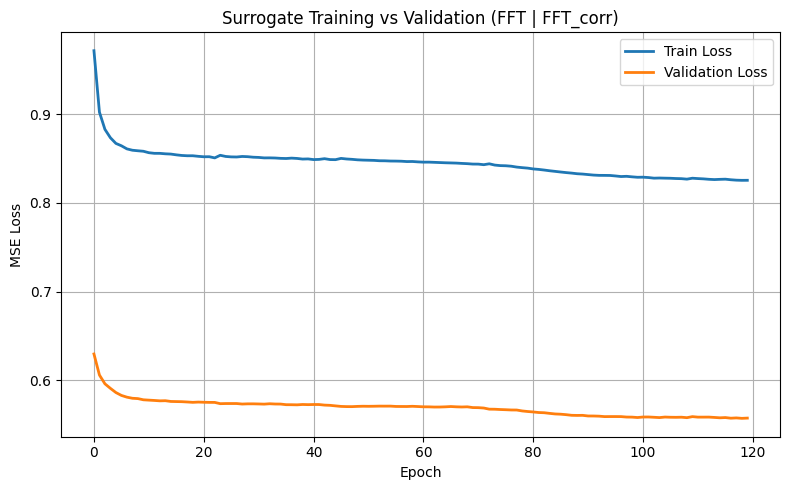


----------------------------------------
 Training surrogate: CORR
----------------------------------------
Phi dimension: 65
Phi mean (train) first 5: tensor([0.9868, 0.9811, 0.9744, 0.9655, 0.9559])
Phi std  (train) first 5: tensor([0.0975, 0.0969, 0.0964, 0.0957, 0.0951])
[CORR] Epoch 001/120 | Train: 0.979478 | Val: 0.711407
[CORR] Epoch 010/120 | Train: 0.779326 | Val: 0.576447
[CORR] Epoch 020/120 | Train: 0.769036 | Val: 0.569642
[CORR] Epoch 030/120 | Train: 0.758956 | Val: 0.560902
[CORR] Epoch 040/120 | Train: 0.742164 | Val: 0.542541
[CORR] Epoch 050/120 | Train: 0.705465 | Val: 0.503100
[CORR] Epoch 060/120 | Train: 0.681564 | Val: 0.482120
[CORR] Epoch 070/120 | Train: 0.676059 | Val: 0.474562
[CORR] Epoch 080/120 | Train: 0.674387 | Val: 0.471992
[CORR] Epoch 090/120 | Train: 0.672362 | Val: 0.471197
[CORR] Epoch 100/120 | Train: 0.670648 | Val: 0.471125
[CORR] Epoch 110/120 | Train: 0.670054 | Val: 0.470404
[CORR] Epoch 120/120 | Train: 0.668270 | Val: 0.469542

Surroga

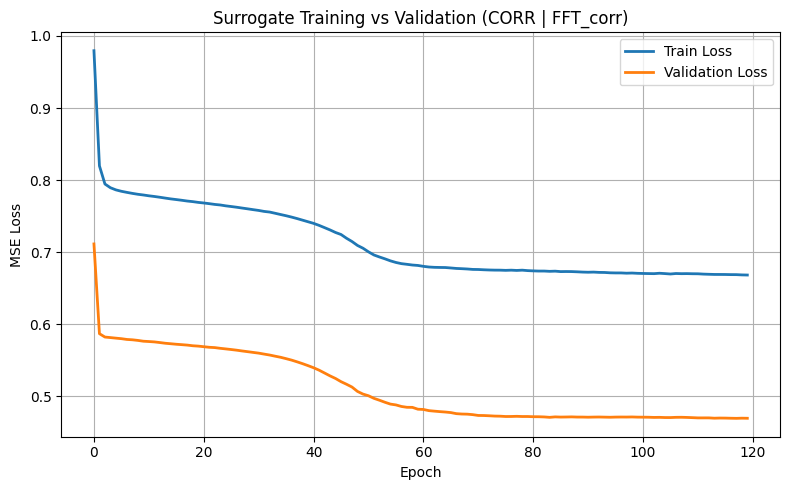

In [8]:
if TRAIN_SURROGATE:

    print("\n==============================")
    print(f" TRAINING SURROGATE MODELS ({RUN_TAG})")
    print("   g_fft(D, sigma)  →  <Phi_fft>")
    print("   g_corr(D, sigma) →  <Phi_corr>")
    print("==============================\n")

    # -------------------------------------------------
    # Helper: load ALL images for one (D, sigma) group
    # (NO augmentations, ONLY ToTensor)
    # -------------------------------------------------
    def load_group_imgs(img_paths, device):
        imgs = []
        for p in img_paths:
            img = Image.open(p).convert("L")
            img = val_tf(img)              # ONLY ToTensor
            img = img.repeat(3, 1, 1)      # [1,H,W] -> [3,H,W]
            imgs.append(img)
        return torch.stack(imgs).to(device)  # [N,3,H,W]


    # -------------------------------------------------
    # Helper: compute Phi_bar for a group (FFT or CORR)
    # -------------------------------------------------
    def compute_group_phi_bar(imgs, physics, n_radial_bins=64):
        """
        imgs: [N, 3, H, W] tensor on device
        returns: Phi_bar [phi_dim]
        """
        with torch.no_grad():
            if physics == "fft":
                Phi = compute_fft_observables(imgs, n_radial_bins=n_radial_bins)   # [N, phi_dim]
            elif physics == "corr":
                Phi = compute_corr_observables(imgs, n_radial_bins=n_radial_bins)  # [N, phi_dim]
            else:
                raise ValueError("physics must be 'fft' or 'corr'")
            Phi_bar = Phi.mean(dim=0)  # [phi_dim]
        return Phi_bar


    # -------------------------------------------------
    # Helper: compute Phi_mean/std from TRAIN surrogate set
    # (using Phi_bar per (D, sigma) group)
    # -------------------------------------------------
    def compute_phi_stats_from_trainset(train_surr, physics, device, n_radial_bins=64):
        Phi_list = []
        with torch.no_grad():
            for item in train_surr:
                imgs = load_group_imgs(item["img_paths"], device)
                Phi_bar = compute_group_phi_bar(imgs, physics, n_radial_bins=n_radial_bins)
                Phi_list.append(Phi_bar.cpu())

        Phi_all = torch.stack(Phi_list, dim=0)  # [n_groups, phi_dim]
        Phi_mean = Phi_all.mean(dim=0)
        Phi_std  = Phi_all.std(dim=0)
        Phi_std[Phi_std == 0] = 1.0

        return Phi_mean.to(device), Phi_std.to(device)


    # -------------------------------------------------
    # Helper: train one surrogate (generic)
    # -------------------------------------------------
    def train_one_surrogate(physics, ckpt_path, curve_path, n_radial_bins=64, epochs=120, lr=1e-3):

        print("\n----------------------------------------")
        print(f" Training surrogate: {physics.upper()}")
        print("----------------------------------------")

        # Determine phi_dim dynamically
        sample_item = train_surr[0]
        sample_imgs = load_group_imgs(sample_item["img_paths"], device)
        with torch.no_grad():
            sample_phi_bar = compute_group_phi_bar(sample_imgs, physics, n_radial_bins=n_radial_bins)
        phi_dim = sample_phi_bar.shape[0]
        print("Phi dimension:", phi_dim)

        # Build model
        surrogate = SurrogatePhysics(phi_dim=phi_dim).to(device)
        optimizer_surr = torch.optim.Adam(surrogate.parameters(), lr=lr)
        criterion = nn.MSELoss()

        # Compute normalization from TRAIN surrogate set
        Phi_mean, Phi_std = compute_phi_stats_from_trainset(
            train_surr, physics, device, n_radial_bins=n_radial_bins
        )

        print("Phi mean (train) first 5:", Phi_mean[:5].detach().cpu())
        print("Phi std  (train) first 5:", Phi_std[:5].detach().cpu())

        train_losses = []
        val_losses = []

        for epoch in range(1, epochs + 1):

            # -----------------------------
            # TRAIN
            # -----------------------------
            surrogate.train()
            running_train = 0.0

            for item in train_surr:
                params = item["params"].to(device)  # [2] physical units
                imgs = load_group_imgs(item["img_paths"], device)

                # target Phi_bar (normalized)
                Phi_bar = compute_group_phi_bar(imgs, physics, n_radial_bins=n_radial_bins)
                Phi_bar = (Phi_bar - Phi_mean) / Phi_std

                Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)  # [phi_dim]

                loss = criterion(Phi_pred, Phi_bar)

                optimizer_surr.zero_grad()
                loss.backward()
                optimizer_surr.step()

                running_train += loss.item()

            train_loss = running_train / len(train_surr)
            train_losses.append(train_loss)

            # -----------------------------
            # VALIDATION
            # -----------------------------
            surrogate.eval()
            running_val = 0.0

            with torch.no_grad():
                for item in val_surr:
                    params = item["params"].to(device)
                    imgs = load_group_imgs(item["img_paths"], device)

                    Phi_bar = compute_group_phi_bar(imgs, physics, n_radial_bins=n_radial_bins)
                    Phi_bar = (Phi_bar - Phi_mean) / Phi_std

                    Phi_pred = surrogate(params.unsqueeze(0)).squeeze(0)

                    running_val += criterion(Phi_pred, Phi_bar).item()

            val_loss = running_val / len(val_surr)
            val_losses.append(val_loss)

            if epoch % 10 == 0 or epoch == 1:
                print(
                    f"[{physics.upper()}] Epoch {epoch:03d}/{epochs} | "
                    f"Train: {train_loss:.6f} | "
                    f"Val: {val_loss:.6f}"
                )

        # Freeze and save
        for p in surrogate.parameters():
            p.requires_grad = False
        surrogate.eval()

        torch.save({
            "state_dict": surrogate.state_dict(),
            "Phi_mean": Phi_mean.detach().cpu(),
            "Phi_std": Phi_std.detach().cpu(),
            "phi_dim": phi_dim,
            "physics": physics,
            "n_radial_bins": n_radial_bins,
            "run_tag": RUN_TAG
        }, ckpt_path)

        print(f"\nSurrogate saved to '{ckpt_path}'")

        # Plot curve
        plt.figure(figsize=(8, 5))
        plt.plot(train_losses, label="Train Loss", linewidth=2)
        plt.plot(val_losses, label="Validation Loss", linewidth=2)
        plt.xlabel("Epoch")
        plt.ylabel("MSE Loss")
        plt.title(f"Surrogate Training vs Validation ({physics.upper()} | {RUN_TAG})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.savefig(curve_path, dpi=300)
        plt.show()

        return surrogate, (Phi_mean, Phi_std)


    # -------------------------------------------------
    # Train BOTH surrogates
    # -------------------------------------------------
    surrogate_fft,  (Phi_fft_mean,  Phi_fft_std)  = train_one_surrogate(
        physics="fft",
        ckpt_path=SURR_FFT_PATH,
        curve_path=FIG_DIR / f"surrogate_train_val_curve_fft_{RUN_TAG}.png",
        n_radial_bins=64,
        epochs=120,
        lr=1e-3
    )

    surrogate_corr, (Phi_corr_mean, Phi_corr_std) = train_one_surrogate(
        physics="corr",
        ckpt_path=SURR_CORR_PATH,
        curve_path=FIG_DIR / f"surrogate_train_val_curve_corr_{RUN_TAG}.png",
        n_radial_bins=64,
        epochs=120,
        lr=1e-3
    )

else:
    print("\n[Info] TRAIN_SURROGATE=False → later we will load checkpoints.\n")


In [9]:
# -----------------------------
# Model Initialization
# PhysicsNormal (FFT + Corr physics)
# -----------------------------

print("\n==============================")
print(f" Initializing PhysicsNormal model ({RUN_TAG}: FFT + C(r) physics)")
print("==============================\n")

# -------------------------------------------------
# CNN: image → (D, sigma)  (normalized targets)
# -------------------------------------------------
model = PhysicsNormalCNN().to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-3
)

criterion = nn.MSELoss()

# -------------------------------------------------
# Load BOTH trained surrogate physics models
# -------------------------------------------------
assert SURR_FFT_PATH.exists(), (
    f"{SURR_FFT_PATH} not found. Train FFT surrogate before training PhysicsNormal."
)
assert SURR_CORR_PATH.exists(), (
    f"{SURR_CORR_PATH} not found. Train Corr surrogate before training PhysicsNormal."
)

# ---------- FFT surrogate ----------
ckpt_fft = torch.load(SURR_FFT_PATH, map_location=device)
phi_fft_dim = ckpt_fft["phi_dim"]
Phi_fft_mean = ckpt_fft["Phi_mean"].to(device)
Phi_fft_std  = ckpt_fft["Phi_std"].to(device)

surrogate_fft = SurrogatePhysics(phi_dim=phi_fft_dim).to(device)
surrogate_fft.load_state_dict(ckpt_fft["state_dict"])
surrogate_fft.eval()
for p in surrogate_fft.parameters():
    p.requires_grad = False

print(f"Loaded FFT surrogate with phi_dim = {phi_fft_dim}")

# ---------- Corr surrogate ----------
ckpt_corr = torch.load(SURR_CORR_PATH, map_location=device)
phi_corr_dim = ckpt_corr["phi_dim"]
Phi_corr_mean = ckpt_corr["Phi_mean"].to(device)
Phi_corr_std  = ckpt_corr["Phi_std"].to(device)

surrogate_corr = SurrogatePhysics(phi_dim=phi_corr_dim).to(device)
surrogate_corr.load_state_dict(ckpt_corr["state_dict"])
surrogate_corr.eval()
for p in surrogate_corr.parameters():
    p.requires_grad = False

print(f"Loaded Corr surrogate with phi_dim = {phi_corr_dim}")

# -------------------------------------------------
# Physics loss weights (start simple)
# You can tune later if one dominates the other.
# -------------------------------------------------
w_fft  = 1.0
w_corr = 1.0

print(f"Physics weights: w_fft={w_fft}, w_corr={w_corr}")

# -------------------------------------------------
# LR scheduler (monitor TOTAL validation loss)
# -------------------------------------------------
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5
)

best_val_loss = float("inf")

BEST_PATH = CKPT_DIR / f"best_physicsnormal_model_{RUN_TAG}.pt"

print(f"PhysicsNormal initialized with LR={LR}")
print(f"Best model will be saved to: {BEST_PATH}\n")



 Initializing PhysicsNormal model (FFT_corr: FFT + C(r) physics)

Loaded FFT surrogate with phi_dim = 70
Loaded Corr surrogate with phi_dim = 65
Physics weights: w_fft=1.0, w_corr=1.0
PhysicsNormal initialized with LR=5e-05
Best model will be saved to: outputs/FFT_corr/checkpoints/best_physicsnormal_model_FFT_corr.pt



Epoch 001 | Train: 7.4687e-01 | Data: 6.6238e-01 | FFT: 9.4128e-01 | Corr: 7.4853e-01 | Val: 5.9121e-01 | λ_phys=0.05 | LR=5.0e-05
 -> Saved new best model.
Epoch 002 | Train: 6.4967e-01 | Data: 4.9628e-01 | FFT: 8.5095e-01 | Corr: 6.8290e-01 | Val: 6.6615e-01 | λ_phys=0.10 | LR=5.0e-05
Epoch 003 | Train: 6.4630e-01 | Data: 4.2049e-01 | FFT: 8.3565e-01 | Corr: 6.6979e-01 | Val: 5.3935e-01 | λ_phys=0.15 | LR=5.0e-05
 -> Saved new best model.
Epoch 004 | Train: 6.6724e-01 | Data: 3.7216e-01 | FFT: 8.0659e-01 | Corr: 6.6882e-01 | Val: 6.3872e-01 | λ_phys=0.20 | LR=5.0e-05
Epoch 005 | Train: 7.1870e-01 | Data: 3.5041e-01 | FFT: 7.9572e-01 | Corr: 6.7745e-01 | Val: 1.0360e+00 | λ_phys=0.25 | LR=5.0e-05
Epoch 006 | Train: 7.6226e-01 | Data: 3.3047e-01 | FFT: 7.6709e-01 | Corr: 6.7222e-01 | Val: 5.9917e-01 | λ_phys=0.30 | LR=5.0e-05
Epoch 007 | Train: 8.0356e-01 | Data: 3.0826e-01 | FFT: 7.5640e-01 | Corr: 6.5875e-01 | Val: 6.0528e-01 | λ_phys=0.35 | LR=5.0e-05
Epoch 008 | Train: 8.4876e-01 |

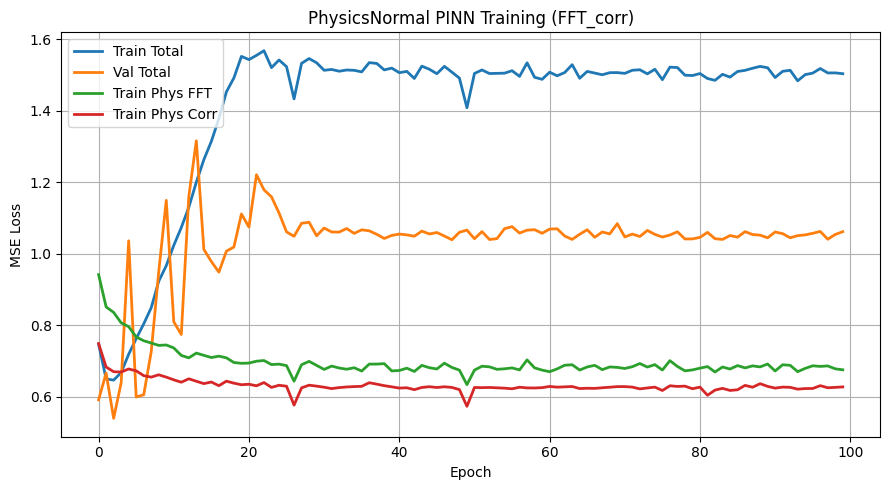

In [10]:
# ============================================================
# Training loop — PhysicsNormal PINN (FFT + Corr)
# ============================================================

train_losses = []
val_losses = []

train_data_losses = []
val_data_losses = []

train_phys_fft = []
train_phys_corr = []

lambda_list = []

lambda_data = 1.0

t_mean_t = torch.tensor(t_mean, device=device, dtype=torch.float32)
t_std_t  = torch.tensor(t_std,  device=device, dtype=torch.float32)

for epoch in range(1, EPOCHS + 1):

    # -------------------------------------------------
    # Physics curriculum (smooth activation)
    # -------------------------------------------------
    lambda_phys = min(1.0, epoch / 20)
    lambda_list.append(lambda_phys)

    # ==========================
    #        TRAIN
    # ==========================
    model.train()

    running_total = 0.0
    running_data  = 0.0
    running_fft   = 0.0
    running_corr  = 0.0

    for imgs, targets in train_loader:
        imgs = imgs.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        # --------------------------
        # Forward CNN
        # --------------------------
        outputs = model(imgs)   # normalized (D, sigma)

        # --------------------------
        # Supervised data loss
        # --------------------------
        loss_data = criterion(outputs, targets)

        # --------------------------
        # Physics targets from image
        # --------------------------
        with torch.no_grad():
            Phi_fft_img  = compute_fft_observables(imgs)
            Phi_corr_img = compute_corr_observables(imgs)

            Phi_fft_img  = (Phi_fft_img  - Phi_fft_mean)  / Phi_fft_std
            Phi_corr_img = (Phi_corr_img - Phi_corr_mean) / Phi_corr_std

        # --------------------------
        # Physics prediction via surrogates
        # --------------------------
        params_phys = outputs * t_std_t + t_mean_t   # unnormalize → physical units

        Phi_fft_pred  = surrogate_fft(params_phys)
        Phi_corr_pred = surrogate_corr(params_phys)

        loss_fft  = F.mse_loss(Phi_fft_pred,  Phi_fft_img)
        loss_corr = F.mse_loss(Phi_corr_pred, Phi_corr_img)

        loss_phys = w_fft * loss_fft + w_corr * loss_corr

        # --------------------------
        # Total loss
        # --------------------------
        loss = lambda_data * loss_data + lambda_phys * loss_phys

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        bs = imgs.size(0)
        running_total += loss.item() * bs
        running_data  += loss_data.item() * bs
        running_fft   += loss_fft.item() * bs
        running_corr  += loss_corr.item() * bs

    epoch_train_loss = running_total / len(train_loader.dataset)
    epoch_train_data = running_data  / len(train_loader.dataset)
    epoch_train_fft  = running_fft   / len(train_loader.dataset)
    epoch_train_corr = running_corr  / len(train_loader.dataset)

    train_losses.append(epoch_train_loss)
    train_data_losses.append(epoch_train_data)
    train_phys_fft.append(epoch_train_fft)
    train_phys_corr.append(epoch_train_corr)

    # ==========================
    #      VALIDATION
    # ==========================
    model.eval()

    running_val = 0.0
    running_val_data = 0.0

    with torch.no_grad():
        for imgs, targets in val_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)

            outputs = model(imgs)
            loss_data = criterion(outputs, targets)

            Phi_fft_img  = compute_fft_observables(imgs)
            Phi_corr_img = compute_corr_observables(imgs)

            Phi_fft_img  = (Phi_fft_img  - Phi_fft_mean)  / Phi_fft_std
            Phi_corr_img = (Phi_corr_img - Phi_corr_mean) / Phi_corr_std

            params_phys = outputs * t_std_t + t_mean_t

            Phi_fft_pred  = surrogate_fft(params_phys)
            Phi_corr_pred = surrogate_corr(params_phys)

            loss_phys = (
                w_fft  * F.mse_loss(Phi_fft_pred,  Phi_fft_img) +
                w_corr * F.mse_loss(Phi_corr_pred, Phi_corr_img)
            )

            loss = lambda_data * loss_data + lambda_phys * loss_phys

            bs = imgs.size(0)
            running_val += loss.item() * bs
            running_val_data += loss_data.item() * bs

    epoch_val_loss = running_val / len(val_loader.dataset)
    epoch_val_data = running_val_data / len(val_loader.dataset)

    val_losses.append(epoch_val_loss)
    val_data_losses.append(epoch_val_data)

    # ==========================
    # Scheduler & logging
    # ==========================
    scheduler.step(epoch_val_loss)
    lr_now = optimizer.param_groups[0]["lr"]

    print(
        f"Epoch {epoch:03d} | "
        f"Train: {epoch_train_loss:.4e} | "
        f"Data: {epoch_train_data:.4e} | "
        f"FFT: {epoch_train_fft:.4e} | "
        f"Corr: {epoch_train_corr:.4e} | "
        f"Val: {epoch_val_loss:.4e} | "
        f"λ_phys={lambda_phys:.2f} | "
        f"LR={lr_now:.1e}"
    )

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save({
            "model_state_dict": model.state_dict(),
            "target_mean": t_mean,
            "target_std": t_std,
            "run_tag": RUN_TAG
        }, BEST_PATH)
        print(" -> Saved new best model.")

# ============================================================
# Plot losses
# ============================================================

plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="Train Total", linewidth=2)
plt.plot(val_losses, label="Val Total", linewidth=2)
plt.plot(train_phys_fft, label="Train Phys FFT", linewidth=2)
plt.plot(train_phys_corr, label="Train Phys Corr", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title(f"PhysicsNormal PINN Training ({RUN_TAG})")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



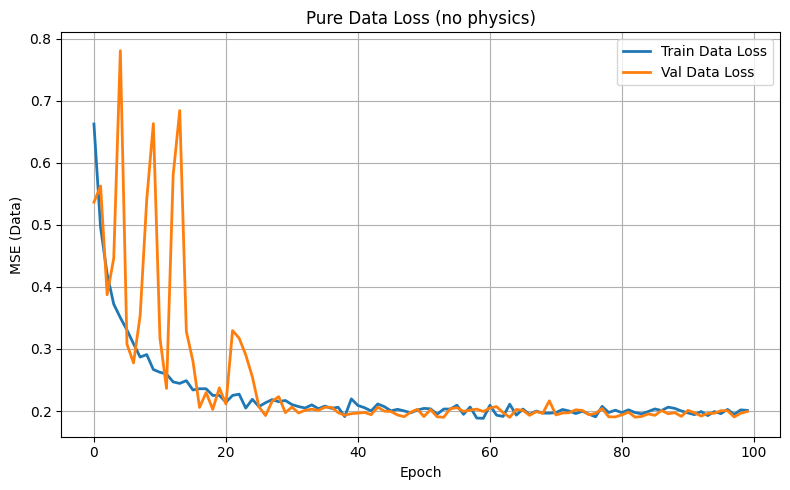

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(train_data_losses, label="Train Data Loss", linewidth=2)
plt.plot(val_data_losses, label="Val Data Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE (Data)")
plt.title("Pure Data Loss (no physics)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("data_loss_curve_4.png", dpi=300)
plt.show()


In [14]:
def get_ground_truth(img_path, df):
    """
    Extract run_id from filename mz_binary_<run_id>.png
    and look up (D, sigma) in a preloaded DataFrame.
    """
    filename = Path(img_path).stem  # mz_binary_123
    try:
        run_id = int(filename.split("_")[-1])
    except ValueError:
        raise ValueError(f"Cannot parse run_id from filename: {filename}")

    row = df[df[IMG_INDEX_COL] == run_id]

    if row.empty:
        raise KeyError(f"run_id {run_id} not found in CSV")

    return float(row.iloc[0][COL_D]), float(row.iloc[0][COL_SIGMA])


def load_model(path, device):
    """
    Load trained PhysicsNormalCNN model for inference.
    Returns model + target normalization.
    """
    checkpoint = torch.load(path, map_location=device, weights_only=False)

    model = PhysicsNormalCNN().to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    target_mean = torch.tensor(
        checkpoint["target_mean"],
        device=device,
        dtype=torch.float32
    )
    target_std = torch.tensor(
        checkpoint["target_std"],
        device=device,
        dtype=torch.float32
    )

    return model, target_mean, target_std



# -------------------------------------------------
# Transform for prediction (NO augmentations)
# -------------------------------------------------
predict_tf = T.Compose([
    T.ToTensor(),
])


In [40]:
# -----------------------------
# 8) Execution: Predict & Compare
# -----------------------------

# -------------------------------------------------
# Prediction function (clean, physical units)
# -------------------------------------------------
def predict_image(img_path, model, target_mean, target_std, device):
    img = Image.open(img_path).convert("L")
    img = predict_tf(img)

    if img.shape[0] == 1:
        img = img.repeat(3, 1, 1)

    img = img.unsqueeze(0).to(device)

    with torch.no_grad():
        out_norm = model(img).squeeze(0)   # normalized (D, sigma)
        out_phys = out_norm * target_std + target_mean

    return float(out_phys[0].item()), float(out_phys[1].item())


# -------------------------------------------------
# Load trained PhysicsNormal model (FFT_corr)
# -------------------------------------------------
model, tm, ts = load_model(BEST_PATH, device)

# Preload CSV once (efficient + clean)
gt_df = pd.read_csv(CSV_PATH)

# Example image
test_img_path = "../dataset_combined/images/mz_binary_176.png"

# Predict
pred_D, pred_sigma = predict_image(
    test_img_path, model, tm, ts, device
)

# Ground truth
real_D, real_sigma = get_ground_truth(test_img_path, gt_df)

# -------------------------------------------------
# Report
# -------------------------------------------------
print("-" * 60)
print(f"Model: PhysicsNormalCNN ({RUN_TAG})")
print(f"Image: {Path(test_img_path).name}")
print("-" * 60)
print(f"{'Parameter':<10} | {'Real':<12} | {'Predicted':<12} | {'Abs Error':<12}")
print("-" * 60)
print(f"{'D':<10} | {real_D:.6f} | {pred_D:.6f} | {abs(pred_D-real_D):.6f}")
print(f"{'Sigma':<10} | {real_sigma:.6f} | {pred_sigma:.6f} | {abs(pred_sigma-real_sigma):.6f}")
print("-" * 60)


------------------------------------------------------------
Model: PhysicsNormalCNN (FFT_corr)
Image: mz_binary_176.png
------------------------------------------------------------
Parameter  | Real         | Predicted    | Abs Error   
------------------------------------------------------------
D          | 0.001293 | 0.001219 | 0.000073
Sigma      | 0.112712 | 0.076122 | 0.036590
------------------------------------------------------------


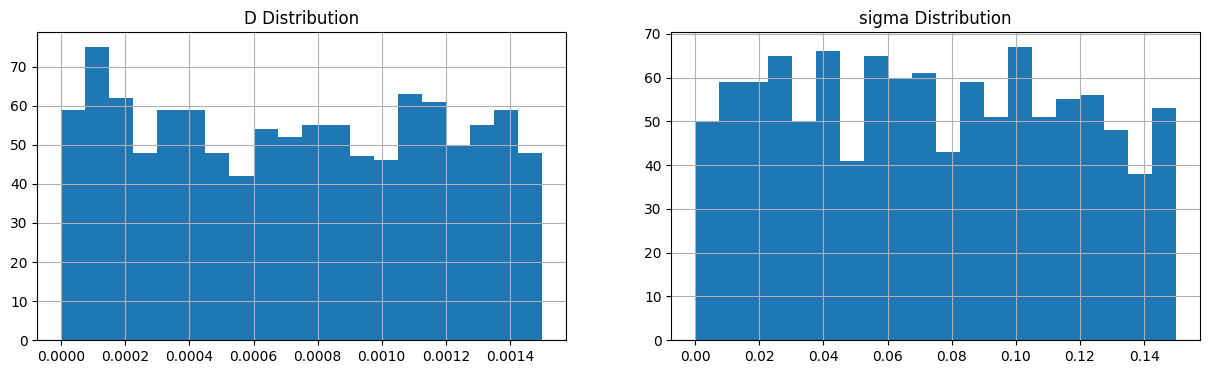

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../dataset_combined/training_index.csv")

plt.figure(figsize=(15,4))
plt.subplot(1,2,1)
df["Dind"].hist(bins=20)
plt.title("D Distribution")

plt.subplot(1,2,2)
df["sigma"].hist(bins=20)
plt.title("sigma Distribution")

plt.show()


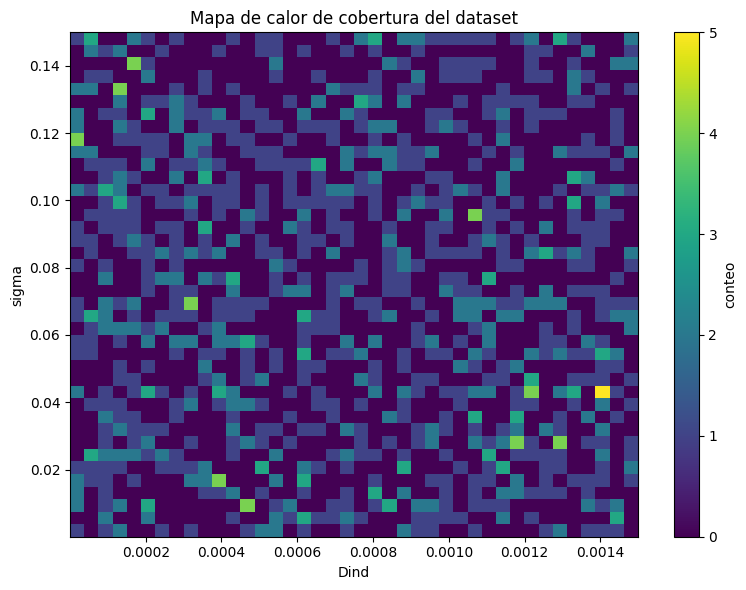

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_D_sigma_heatmap(
    csv_path,
    D_col="Dind",
    sigma_col="sigma",
    bins_D=30,
    bins_sigma=30,
    log_scale=True
):
    """
    Genera un mapa de calor del conteo de muestras en el plano (D, sigma)

    Parameters
    ----------
    csv_path : str
        Ruta al archivo CSV
    D_col : str
        Nombre de la columna de D
    sigma_col : str
        Nombre de la columna de sigma
    bins_D : int
        Número de bins para D
    bins_sigma : int
        Número de bins para sigma
    log_scale : bool
        Si True, usa escala logarítmica para el color
    """

    # ---------------------------
    # Leer datos
    # ---------------------------
    df = pd.read_csv(csv_path)

    if D_col not in df.columns or sigma_col not in df.columns:
        raise ValueError("Las columnas especificadas no existen en el CSV")

    D = df[D_col].values
    sigma = df[sigma_col].values


    # ---------------------------
    # Binning y conteo
    # ---------------------------
    H, D_edges, sigma_edges = np.histogram2d(
        D,
        sigma,
        bins=[bins_D, bins_sigma]
    )

    if log_scale:
        H = np.log10(H + 1.0)

    # ---------------------------
    # Plot
    # ---------------------------
    plt.figure(figsize=(8, 6))

    extent = [
        D_edges[0], D_edges[-1],
        sigma_edges[0], sigma_edges[-1]
    ]

    im = plt.imshow(
        H.T,
        origin="lower",
        aspect="auto",
        extent=extent
    )

    cbar = plt.colorbar(im)
    cbar.set_label("log10(conteo + 1)" if log_scale else "conteo")

    plt.xlabel(D_col)
    plt.ylabel(sigma_col)
    plt.title("Mapa de calor de cobertura del dataset")

    plt.tight_layout()
    plt.savefig("D_sigma_heatmap_combined_1000.png", dpi=300)
    plt.show()


plot_D_sigma_heatmap(
    csv_path="../dataset_combined/training_index.csv",
    D_col="Dind",
    sigma_col="sigma",
    bins_D=40,
    bins_sigma=40,
    log_scale=False
)


In [27]:
from pathlib import Path
import pandas as pd
from tqdm import tqdm


def collect_prediction_errors(
    image_dir,
    df_gt,
    model,
    target_mean,
    target_std,
    device,
):
    """
    Run inference on all images listed in df_gt and
    collect prediction errors for D and sigma.

    Parameters
    ----------
    image_dir : str or Path
        Directory containing mz_binary_<run_id>.png images
    df_gt : pd.DataFrame
        Ground-truth DataFrame (loaded once)
    model : torch.nn.Module
        Trained PhysicsNormalCNN
    target_mean, target_std : torch.Tensor
        Normalization tensors (on device)
    device : torch.device
    """

    records = []
    image_dir = Path(image_dir)

    for row in tqdm(df_gt.itertuples(index=False), total=len(df_gt), desc="Predicting"):
        run_id = int(getattr(row, IMG_INDEX_COL))
        img_path = image_dir / f"{IMG_PREFIX}{run_id}{IMG_EXT}"

        if not img_path.exists():
            raise FileNotFoundError(
                f"Missing image for run_id={run_id}: {img_path}"
            )

        # --------------------------
        # Ground truth
        # --------------------------
        real_D = float(getattr(row, COL_D))
        real_sigma = float(getattr(row, COL_SIGMA))

        # --------------------------
        # Prediction
        # --------------------------
        pred_D, pred_sigma = predict_image(
            img_path,
            model,
            target_mean,
            target_std,
            device
        )

        records.append({
            "run_id": run_id,
            "Dind": real_D,
            "sigma": real_sigma,
            "pred_D": pred_D,
            "pred_sigma": pred_sigma,
            "err_D": abs(pred_D - real_D),
            "err_sigma": abs(pred_sigma - real_sigma),
        })

    return pd.DataFrame.from_records(records)


# -------------------------------------------------
# Run evaluation
# -------------------------------------------------

# Load GT once
df_gt = pd.read_csv(CSV_PATH)

df_err = collect_prediction_errors(
    image_dir=IMG_DIR,
    df_gt=df_gt,
    model=model,
    target_mean=tm,
    target_std=ts,
    device=device,
)

print(df_err.head(20))


Predicting: 100%|██████████| 1097/1097 [00:06<00:00, 171.65it/s]

    run_id      Dind     sigma    pred_D  pred_sigma     err_D  err_sigma
0        1  0.000775  0.130362  0.000661    0.104176  0.000114   0.026186
1        2  0.000195  0.109493  0.000440    0.078865  0.000245   0.030628
2        3  0.000128  0.036694  0.000526    0.028995  0.000397   0.007699
3        4  0.001058  0.096923  0.000919    0.084648  0.000139   0.012275
4        5  0.000142  0.106838  0.000379    0.091402  0.000237   0.015436
5        6  0.001184  0.032805  0.000750    0.019527  0.000435   0.013277
6        7  0.001489  0.015690  0.000971    0.032592  0.000518   0.016902
7        8  0.000726  0.056322  0.000574    0.057596  0.000152   0.001273
8        9  0.000985  0.016908  0.000715    0.017882  0.000270   0.000974
9       10  0.001339  0.105349  0.001186    0.099896  0.000153   0.005453
10      11  0.000732  0.019705  0.001151    0.037002  0.000419   0.017296
11      12  0.001383  0.008773  0.001065    0.020262  0.000317   0.011489
12      13  0.000254  0.031142  0.0007

In [24]:
import numpy as np
import matplotlib.pyplot as plt


def plot_error_heatmap(
    df_err,
    df_limits,
    D_col="Dind",
    sigma_col="sigma",
    err_col="err_D",
    bins_D=40,
    bins_sigma=40,
    statistic="mean",          # "mean" or "median"
    title="",
    cmap="inferno",
    vmin=None,
    vmax=None,
    save_path=None
):
    """
    Heatmap of prediction error in the (D, sigma) plane.

    The physical domain is defined by df_limits
    (typically the training CSV).

    statistic:
        "mean"   → average error per bin
        "median" → median error per bin (robust)
    """

    # --------------------------------------------------
    # 1. Physical domain (authoritative)
    # --------------------------------------------------
    df_limits = df_limits.dropna(subset=[D_col, sigma_col])

    D_min, D_max = df_limits[D_col].min(), df_limits[D_col].max()
    s_min, s_max = df_limits[sigma_col].min(), df_limits[sigma_col].max()

    print(f"[Domain] D:     {D_min:.6g} → {D_max:.6g}")
    print(f"[Domain] sigma: {s_min:.6g} → {s_max:.6g}")

    if D_min == D_max or s_min == s_max:
        raise ValueError("Degenerate range in D or sigma")

    # --------------------------------------------------
    # 2. Physical bins
    # --------------------------------------------------
    D_edges = np.linspace(D_min, D_max, bins_D + 1)
    s_edges = np.linspace(s_min, s_max, bins_sigma + 1)

    # --------------------------------------------------
    # 3. Clean error data
    # --------------------------------------------------
    df = df_err.dropna(subset=[D_col, sigma_col, err_col])

    D = df[D_col].values
    s = df[sigma_col].values
    e = df[err_col].values

    # --------------------------------------------------
    # 4. Bin assignment
    # --------------------------------------------------
    iD = np.searchsorted(D_edges, D, side="right") - 1
    iS = np.searchsorted(s_edges, s, side="right") - 1

    valid = (
        (iD >= 0) & (iD < bins_D) &
        (iS >= 0) & (iS < bins_sigma)
    )

    iD, iS, e = iD[valid], iS[valid], e[valid]

    # --------------------------------------------------
    # 5. Accumulate statistics
    # --------------------------------------------------
    heatmap = np.full((bins_D, bins_sigma), np.nan)
    counts  = np.zeros((bins_D, bins_sigma), dtype=int)

    if statistic == "mean":
        sum_err = np.zeros((bins_D, bins_sigma), dtype=float)

        np.add.at(sum_err, (iD, iS), e)
        np.add.at(counts,  (iD, iS), 1)

        with np.errstate(divide="ignore", invalid="ignore"):
            heatmap = sum_err / counts
            heatmap[counts == 0] = np.nan

    elif statistic == "median":
        bins = [[[] for _ in range(bins_sigma)] for _ in range(bins_D)]
        for d, s_, err in zip(iD, iS, e):
            bins[d][s_].append(err)

        for i in range(bins_D):
            for j in range(bins_sigma):
                if bins[i][j]:
                    heatmap[i, j] = np.median(bins[i][j])
                    counts[i, j] = len(bins[i][j])

    else:
        raise ValueError("statistic must be 'mean' or 'median'")

    # --------------------------------------------------
    # 6. Plot (D on x, sigma on y)
    # --------------------------------------------------
    plt.figure(figsize=(8, 6))
    im = plt.imshow(
        heatmap.T,
        origin="lower",
        aspect="auto",
        extent=[D_min, D_max, s_min, s_max],
        cmap=cmap,
        vmin=vmin,
        vmax=vmax
    )

    cbar = plt.colorbar(im)
    cbar.set_label(err_col)

    plt.xlabel(D_col)
    plt.ylabel(sigma_col)
    plt.title(title)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300)

    plt.show()

    return heatmap, counts


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


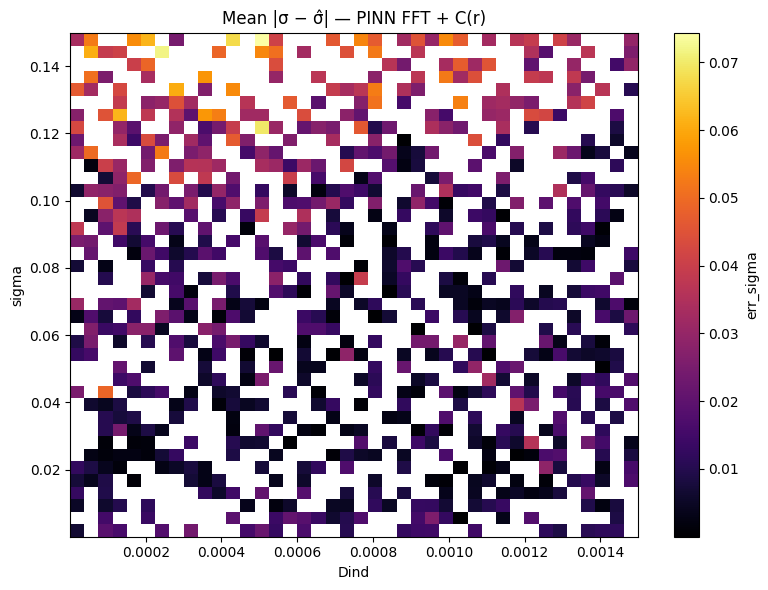

(array([[0.00642615,        nan, 0.00520542, ...,        nan,        nan,
         0.03311182],
        [       nan,        nan,        nan, ...,        nan, 0.06088965,
         0.05282346],
        [0.01906679, 0.01528213, 0.00600253, ...,        nan, 0.03914171,
                nan],
        ...,
        [0.01188915,        nan, 0.00215505, ...,        nan,        nan,
                nan],
        [0.01178325, 0.00893731, 0.0080135 , ..., 0.01531408,        nan,
                nan],
        [       nan,        nan,        nan, ..., 0.02938357, 0.02557118,
         0.0298822 ]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 2, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [1, 3, 2, ..., 2, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [25]:
df_limits = pd.read_csv(CSV_PATH)

# Error en sigma (clave para tu tesis)
plot_error_heatmap(
    df_err=df_err,
    df_limits=df_limits,
    err_col="err_sigma",
    statistic="mean",
    title="Mean |σ − σ̂| — PINN FFT + C(r)",
    save_path=FIG_DIR / "heatmap_err_sigma_FFT_corr.png"
)

[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


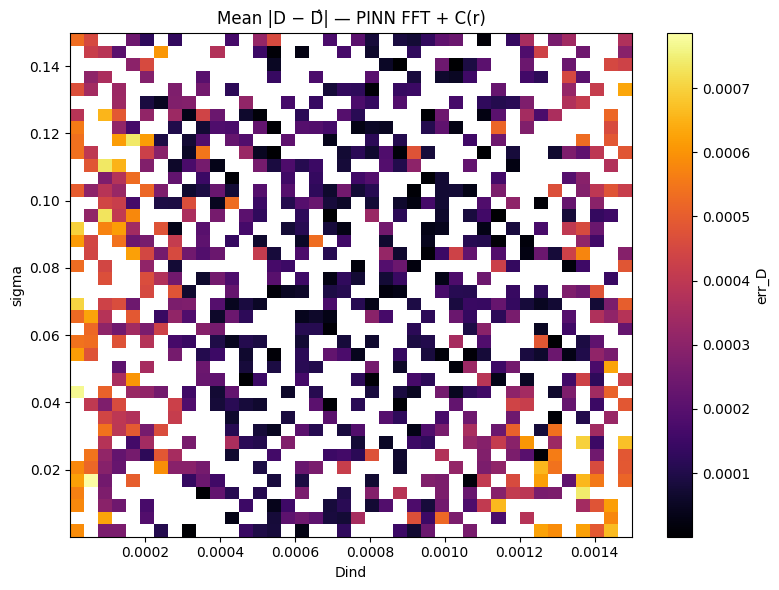

(array([[0.00058707,        nan, 0.00058153, ...,        nan,        nan,
         0.00053345],
        [       nan,        nan,        nan, ...,        nan, 0.00042286,
         0.00045362],
        [0.0002658 , 0.00062684, 0.00029766, ...,        nan, 0.00038771,
                nan],
        ...,
        [0.00049066,        nan, 0.00047956, ...,        nan,        nan,
                nan],
        [0.00066472, 0.00057839, 0.0006195 , ..., 0.00045061,        nan,
                nan],
        [       nan,        nan,        nan, ..., 0.00043467, 0.00029445,
         0.00036893]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 2, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [1, 3, 2, ..., 2, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [26]:
# Error en D (control)
plot_error_heatmap(
    df_err=df_err,
    df_limits=df_limits,
    err_col="err_D",
    statistic="mean",
    title="Mean |D − D̂| — PINN FFT + C(r)",
    save_path=FIG_DIR / "heatmap_err_D_FFT_corr.png"
)


In [28]:
def collect_surrogate_errors(
    surr_dataset,
    surrogate,
    Phi_mean,
    Phi_std,
    compute_phi_bar_fn,
    device,
):
    """
    Evaluate surrogate error per (D, sigma).

    compute_phi_bar_fn:
        function(img_paths, device) -> Phi_bar (REAL)
    """

    records = []

    surrogate.eval()

    with torch.no_grad():
        for item in surr_dataset:
            params = item["params"].to(device)  # [2]
            img_paths = item["img_paths"]

            # True Phi_bar from images
            Phi_bar_real = compute_phi_bar_fn(img_paths, device)
            Phi_bar_real = (Phi_bar_real - Phi_mean) / Phi_std

            # Surrogate prediction
            Phi_bar_pred = surrogate(params.unsqueeze(0)).squeeze(0)

            # Error (L2 norm in Phi-space)
            err_phi = torch.norm(Phi_bar_pred - Phi_bar_real).item()

            records.append({
                "Dind": float(params[0].item()),
                "sigma": float(params[1].item()),
                "err_phi": err_phi
            })

    return pd.DataFrame(records)


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


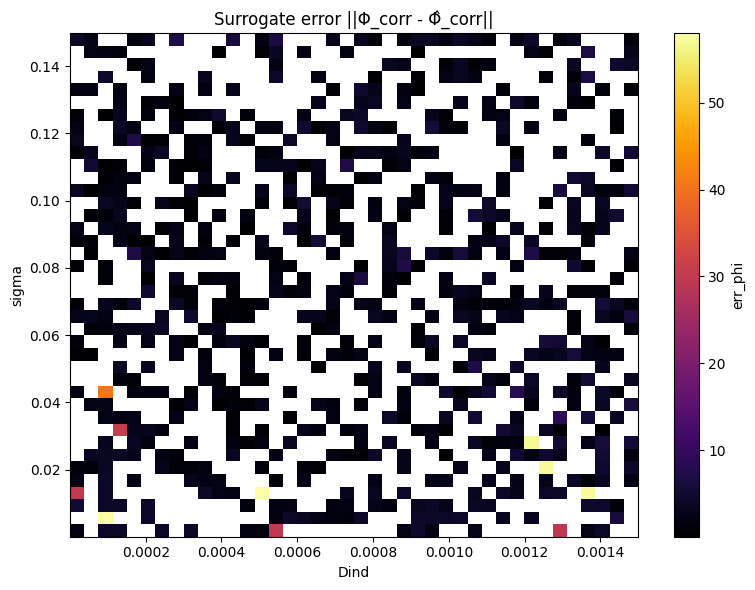

(array([[ 1.97048044,         nan,  5.19867188, ...,         nan,
                 nan,  4.35924482],
        [        nan,         nan,         nan, ...,         nan,
          2.32182807,  2.45266235],
        [ 4.31725454, 57.90813828,  4.11096525, ...,         nan,
          2.06786871,         nan],
        ...,
        [ 4.1099925 ,         nan,  4.54499722, ...,         nan,
                 nan,         nan],
        [        nan,  6.11934423,  1.40718931, ...,  4.67806387,
                 nan,         nan],
        [        nan,         nan,         nan, ...,  4.02853644,
          2.60774183,  1.35940695]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 1, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [0, 3, 2, ..., 1, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [32]:
df_surr_err_corr = collect_surrogate_errors(
    surr_dataset=train_surr,   # o val_surr
    surrogate=surrogate_corr,
    Phi_mean=Phi_corr_mean,
    Phi_std=Phi_corr_std,
    compute_phi_bar_fn=compute_phi_bar_corr,
    device=device
)

plot_error_heatmap(
    df_err=df_surr_err_corr,
    df_limits=df_limits,
    err_col="err_phi",
    title="Surrogate error ||Φ_corr - Φ̂_corr||",
    save_path=FIG_DIR / "heatmap_surrogate_corr_error.png"
)


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


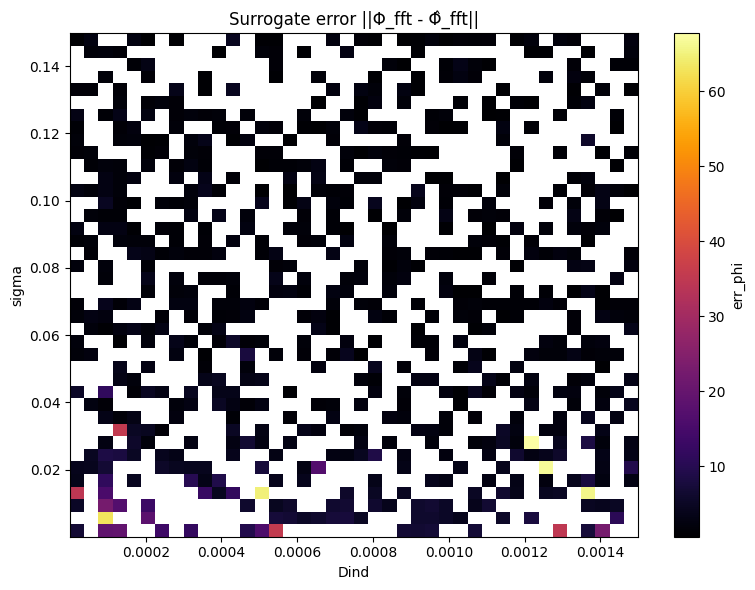

(array([[ 6.77123117,         nan,  5.21728635, ...,         nan,
                 nan,  0.69427729],
        [        nan,         nan,         nan, ...,         nan,
          1.78463721,  2.4942344 ],
        [19.0670948 , 62.8477478 , 22.63540459, ...,         nan,
          2.09859872,         nan],
        ...,
        [22.45915222,         nan,  4.24019146, ...,         nan,
                 nan,         nan],
        [        nan, 10.80120977,  5.04717064, ...,  1.1240989 ,
                 nan,         nan],
        [        nan,         nan,         nan, ...,  1.36950842,
          2.05219722,  2.24049032]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 1, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [0, 3, 2, ..., 1, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [33]:
df_surr_err_fft = collect_surrogate_errors(
    surr_dataset=train_surr,          # o val_surr (mejor usar val)
    surrogate=surrogate_fft,
    Phi_mean=Phi_fft_mean,
    Phi_std=Phi_fft_std,
    compute_phi_bar_fn=compute_phi_bar_fft,
    device=device
)

plot_error_heatmap(
    df_err=df_surr_err_fft,
    df_limits=df_limits,
    err_col="err_phi",
    title="Surrogate error ||Φ_fft - Φ̂_fft||",
    save_path=FIG_DIR / "heatmap_surrogate_fft_error.png"
)



In [34]:
def summarize_err(df, col="err_phi"):
    x = df[col].dropna().values
    print("N:", len(x))
    print("min/median/mean/max:", x.min(), np.median(x), x.mean(), x.max())
    for q in [0.9, 0.95, 0.99]:
        print(f"p{int(q*100)}:", np.quantile(x, q))

summarize_err(df_surr_err_corr, "err_phi")
summarize_err(df_surr_err_fft,  "err_phi")


N: 933
min/median/mean/max: 0.05494440719485283 2.069944381713867 2.982969098132491 58.231101989746094
p90: 4.631084728240971
p95: 5.910117721557617
p99: 31.513448486326716
N: 933
min/median/mean/max: 0.4493953287601471 1.9875651597976685 3.436617344234534 67.81924438476562
p90: 5.508605003356938
p95: 7.746225357055664
p99: 23.029521789550753


[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


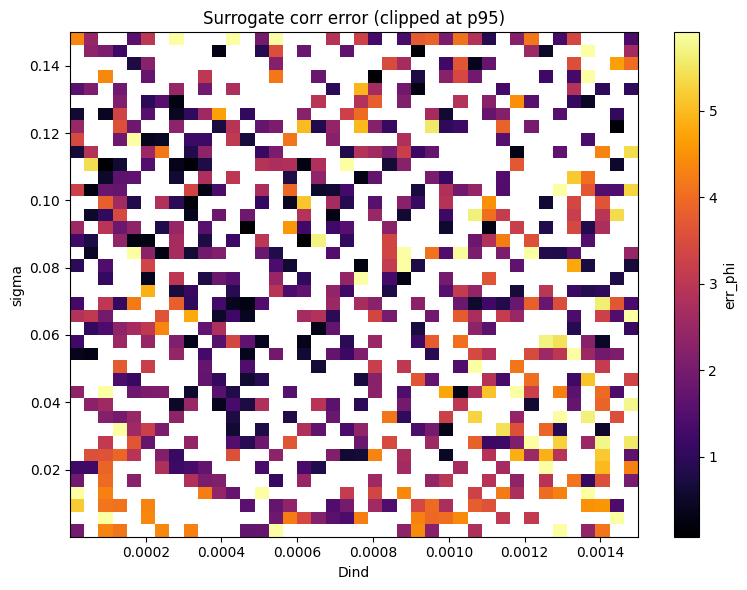

[Domain] D:     1.06272e-07 → 0.00149959
[Domain] sigma: 6.77804e-05 → 0.149908


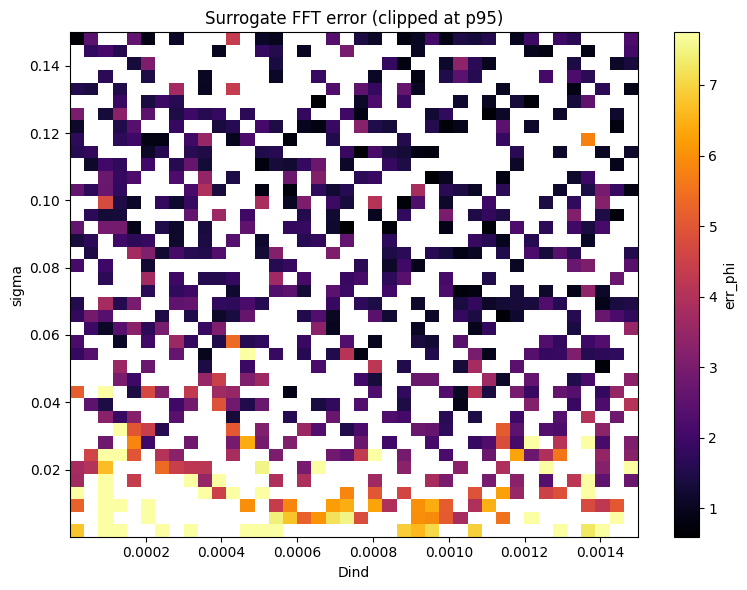

(array([[ 6.77123117,         nan,  5.21728635, ...,         nan,
                 nan,  0.69427729],
        [        nan,         nan,         nan, ...,         nan,
          1.78463721,  2.4942344 ],
        [19.0670948 , 62.8477478 , 22.63540459, ...,         nan,
          2.09859872,         nan],
        ...,
        [22.45915222,         nan,  4.24019146, ...,         nan,
                 nan,         nan],
        [        nan, 10.80120977,  5.04717064, ...,  1.1240989 ,
                 nan,         nan],
        [        nan,         nan,         nan, ...,  1.36950842,
          2.05219722,  2.24049032]], shape=(40, 40)),
 array([[1, 0, 2, ..., 0, 0, 1],
        [0, 0, 0, ..., 0, 2, 3],
        [1, 1, 1, ..., 0, 1, 0],
        ...,
        [1, 0, 1, ..., 0, 0, 0],
        [0, 3, 2, ..., 1, 0, 0],
        [0, 0, 0, ..., 2, 1, 2]], shape=(40, 40)))

In [35]:
vmax_corr = np.quantile(df_surr_err_corr["err_phi"].dropna(), 0.95)
plot_error_heatmap(
    df_err=df_surr_err_corr,
    df_limits=df_limits,
    err_col="err_phi",
    title="Surrogate corr error (clipped at p95)",
    vmax=vmax_corr
)

vmax_fft = np.quantile(df_surr_err_fft["err_phi"].dropna(), 0.95)
plot_error_heatmap(
    df_err=df_surr_err_fft,
    df_limits=df_limits,
    err_col="err_phi",
    title="Surrogate FFT error (clipped at p95)",
    vmax=vmax_fft
)
